In [12]:
#Save
joblib.dump(
    model,
    "../models/xgboost_model.pkl"
)

['../models/xgboost_model.pkl']

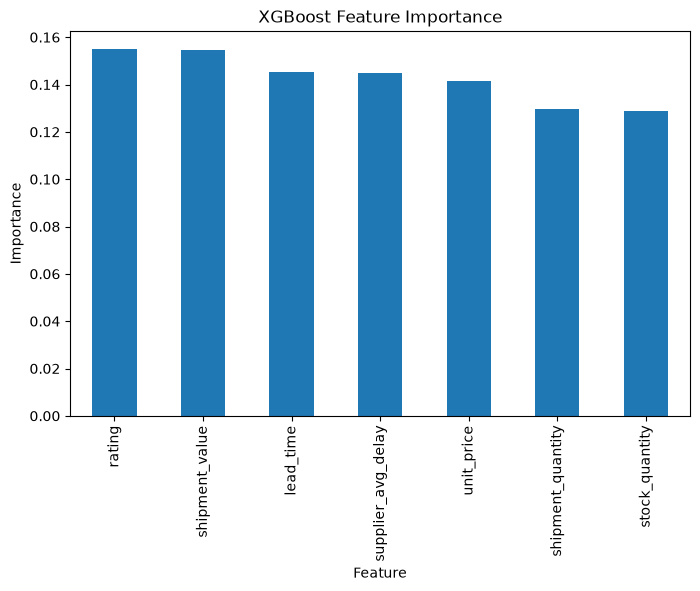

In [11]:
#Polt
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.show()

In [10]:
#Feature Importances
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

              Feature  Importance
4              rating    0.154944
5      shipment_value    0.154647
2           lead_time    0.145398
6  supplier_avg_delay    0.144717
1          unit_price    0.141688
0   shipment_quantity    0.129729
3      stock_quantity    0.128878


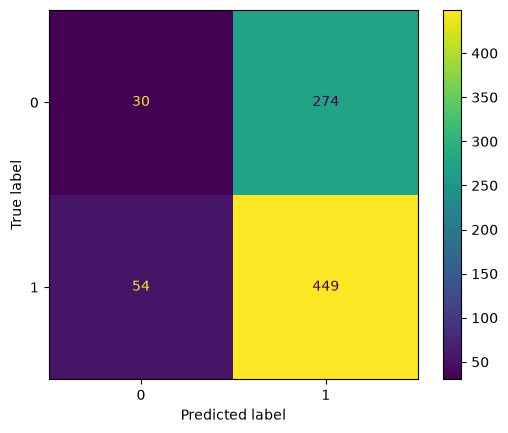

In [9]:
#Confusion Martix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.show()

In [8]:
#Classification Report 
print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.36      0.10      0.15       304
           1       0.62      0.89      0.73       503

    accuracy                           0.59       807
   macro avg       0.49      0.50      0.44       807
weighted avg       0.52      0.59      0.51       807



In [7]:
#Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.5935563816604709


In [6]:
#Make Prediction
predictions = model.predict(X_test)

In [5]:
#Train XGBoost
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [4]:
#Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [3]:
#Select Feature
features = [
    "shipment_quantity",
    "unit_price",
    "lead_time",
    "stock_quantity",
    "rating",
    "shipment_value",
    "supplier_avg_delay"
]

X = df[features]

y = df["is_delayed"]

In [2]:
df = pd.read_csv("../data/feature_engineered_supply_chain.csv")

df.head()

,shipment_id,supplier_id,product_id,shipment_date,expected_arrival,actual_arrival,shipment_quantity,shipment_status,product_name,category,...,shipment_month,shipment_year,shipment_quarter,shipment_weekday,is_delayed,delay_category,high_severity,large_shipment,inventory_status,shipment_value
0,1,6,29,2025-06-03,2025-06-07,2025-06-12,16,In Transit,Architecto Product,Furniture,...,June,2025,2,Tuesday,1,Major Delay,0,0,High,66932.96
1,2,7,84,2025-06-16,2025-06-26,2025-06-24,106,Delayed,Ab Product,Clothing,...,June,2025,2,Monday,0,On Time,0,0,Low,117507.36
2,3,9,119,2026-03-17,2026-03-23,2026-03-24,325,In Transit,Maxime Product,Furniture,...,March,2026,1,Tuesday,1,Minor Delay,1,1,High,1558355.50
3,4,5,140,2025-04-20,2025-04-23,2025-04-28,419,Cancelled,Recusandae Product,Groceries,...,April,2025,2,Sunday,1,Major Delay,0,1,High,1133625.45
4,5,18,56,2025-11-20,2025-11-23,2025-11-28,136,Delayed,Error Product,Electronics,...,November,2025,4,Thursday,1,Major Delay,0,0,High,45312.48


In [1]:
# Day 6 - XGBoost Model
## SupplyPrescript - Shipment Delay Prediction using XGBoost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier